In [21]:
from sympy import *
x, c = symbols('x c')
init_printing(use_unicode=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from tqdm import tqdm

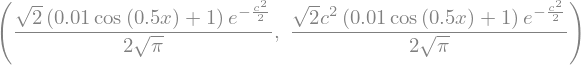

In [22]:
alpha = 0.01
k = 0.5
f_twostream = 1 / sqrt(2 * pi) * exp(-c**2/2) * c**2 * (1 + alpha * cos(k * x))
# v0 = 2.0
# f_twostream = 0.5 / sqrt(2 * pi) * (exp(-(c - v0)**2 / 2) + exp(-(c + v0)**2 / 2))
f_landau = 1 / sqrt(2 * pi) * exp(-c**2/2) * (1 + alpha * cos(k * x))
f_landau, f_twostream

In [23]:
x_range = np.linspace(0, 4*np.pi, 101)
c_range = np.linspace(-5, 5, 101)

In [24]:
f_twostream_contourf = []
f_landau_contourf = []

for x_ in x_range:
    for c_ in c_range:
        f_twostream_contourf.append(f_twostream.subs({x: x_, c: c_}))
        f_landau_contourf.append(f_landau.subs({x: x_, c: c_}))

f_twostream_contourf = np.array(f_twostream_contourf).astype(np.float64)
f_twostream_contourf = f_twostream_contourf.reshape(101, 101).T

f_landau_contourf = np.array(f_landau_contourf).astype(np.float64)
f_landau_contourf = f_landau_contourf.reshape(101, 101).T

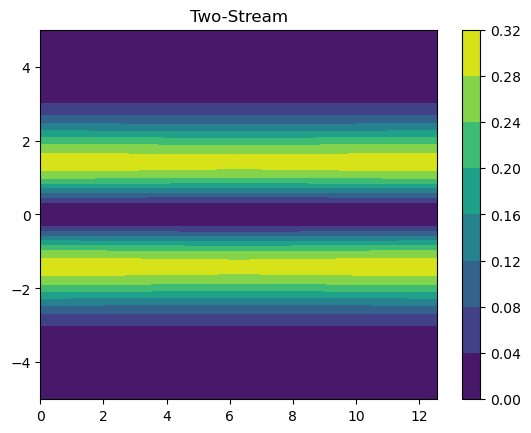

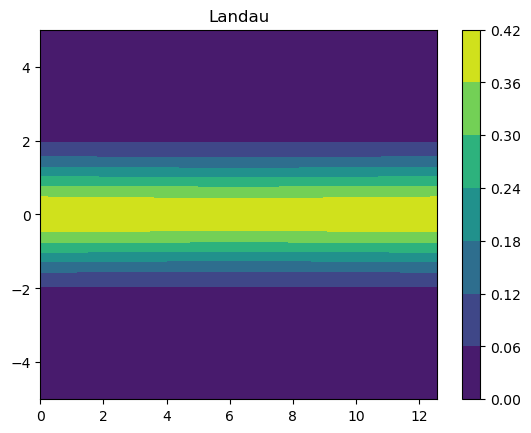

In [25]:
plt.figure()
plt.title("Two-Stream")
plt.contourf(
    x_range, c_range,
    f_twostream_contourf
)
plt.colorbar()
plt.show()

plt.figure()
plt.title("Landau")
plt.contourf(
    x_range, c_range,
    f_landau_contourf
)
plt.colorbar()
plt.show()

In [26]:
rho_twostream, v_twostream, theta_twostream = [], [], []
rho_landau, v_landau, theta_landau = [], [], []
for x_ in x_range:
    f_c_twostream, f_c_landau = [], []
    for c_ in c_range:
        f_c_twostream.append(f_twostream.subs({x:x_, c:c_}))
        f_c_landau.append(f_landau.subs({x:x_, c:c_}))

    rho_twostream.append(np.trapz(f_c_twostream, c_range))
    v_twostream.append(np.trapz(f_c_twostream * c_range, c_range) / rho_twostream[-1])
    theta_twostream.append(np.trapz(f_c_twostream * c_range * c_range, c_range) / rho_twostream[-1])
    rho_landau.append(np.trapz(f_c_landau, c_range))
    v_landau.append(np.trapz(f_c_landau * c_range, c_range) / rho_landau[-1])
    theta_landau.append(np.trapz(f_c_landau * c_range * c_range, c_range) / rho_landau[-1])

rho_twostream = np.array(rho_twostream)
v_twostream = np.array(v_twostream)
theta_twostream = np.array(theta_twostream)
rho_landau = np.array(rho_landau)
v_landau = np.array(v_landau)
theta_landau = np.array(theta_landau)

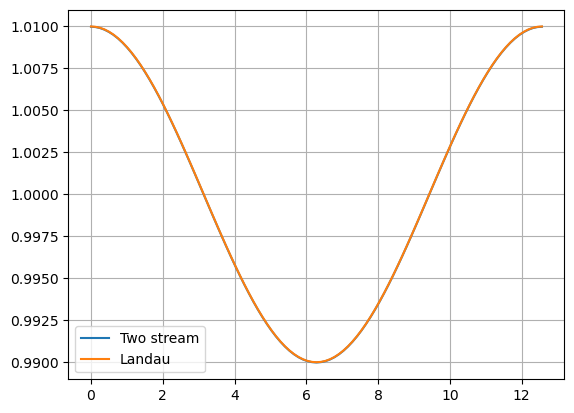

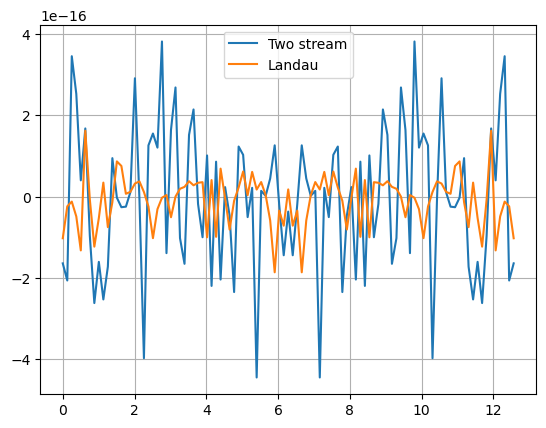

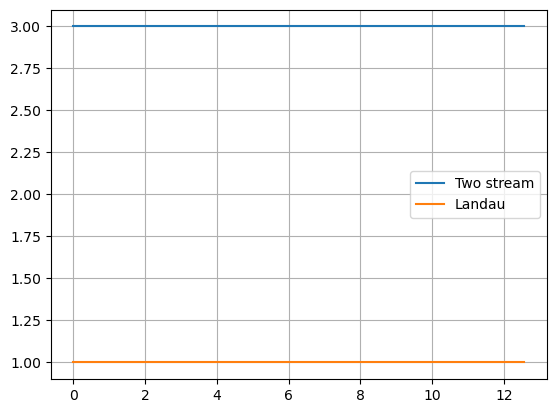

In [27]:
plt.figure()
plt.plot(x_range, rho_twostream, label="Two stream")
plt.plot(x_range, rho_landau, label="Landau")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(x_range, v_twostream, label="Two stream")
plt.plot(x_range, v_landau, label="Landau")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(x_range, theta_twostream, label="Two stream")
plt.plot(x_range, theta_landau, label="Landau")
plt.legend()
plt.grid()
plt.show()

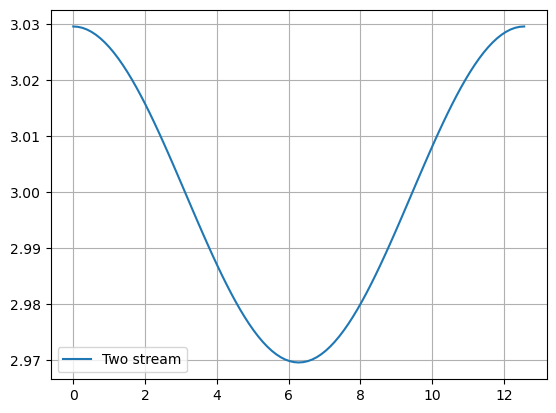

In [29]:
plt.figure()
plt.plot(x_range, theta_twostream * rho_twostream, label="Two stream")
# plt.plot(x_range, theta_landau, label="Landau")
plt.legend()
plt.grid()
plt.show()